# Proyecto de Machine Learning No Supervisado
## Parte 2: Segmentación de clientes de tarjetas de crédito

Este notebook estudia el comportamiento de clientes de tarjetas de crédito y construye segmentos que puedan interpretarse en términos de negocio.

### Objetivo

Descubrir grupos de clientes con patrones de saldo, compras, adelantos, pagos y uso del crédito diferentes, sin disponer de una etiqueta que indique cuál es la segmentación correcta.

### Entradas

- Archivo `data/credit_card.csv`.
- Una fila por cliente.
- Un identificador (`CUST_ID`) y 17 variables numéricas de comportamiento durante seis meses.

### Salidas

- Comparación de K-Means, clustering aglomerativo, Gaussian Mixture y DBSCAN.
- Métricas internas de calidad.
- Visualizaciones PCA y t-SNE.
- Perfiles interpretables y propuestas de acciones para cada segmento.
- Clientes atípicos detectados mediante Isolation Forest.

### Criterios de éxito

Una segmentación será útil si combina separación interna razonable, estabilidad ante distintas inicializaciones, tamaños de grupo suficientes e interpretación de negocio clara.

### Riesgos

No existe una verdad de referencia. Las métricas internas no garantizan utilidad comercial y los nombres asignados a los segmentos son interpretaciones que deberían validarse con especialistas del negocio.


## Contexto del dataset

[Credit Card Dataset for Clustering](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata)

El dataset resume seis meses de actividad. A diferencia del notebook de setas, aquí **no existe una etiqueta**:

- no podemos calcular accuracy, ARI o NMI frente a una respuesta real;
- no podemos afirmar que un cliente esté correctamente clasificado;
- evaluaremos cohesión, separación, estabilidad e interpretabilidad;
- el objetivo no es descubrir una única verdad, sino construir una representación útil y defendible.

### Diccionario resumido

| Variable | Interpretación |
|---|---|
| `CUST_ID` | Identificador del cliente; sirve para trazabilidad, no para calcular distancias. |
| `BALANCE` | Saldo disponible o mantenido en la cuenta. |
| `BALANCE_FREQUENCY` | Frecuencia con la que se actualiza o mantiene saldo. |
| `PURCHASES` | Importe total de compras. |
| `ONEOFF_PURCHASES` | Compras realizadas en un solo pago. |
| `INSTALLMENTS_PURCHASES` | Compras realizadas a plazos. |
| `CASH_ADVANCE` | Importe de adelantos de efectivo. |
| `*_FREQUENCY` | Frecuencia del comportamiento correspondiente, normalmente entre 0 y 1. |
| `CASH_ADVANCE_TRX` | Número de operaciones de adelanto. |
| `PURCHASES_TRX` | Número de transacciones de compra. |
| `CREDIT_LIMIT` | Límite de crédito. |
| `PAYMENTS` | Importe de pagos realizados. |
| `MINIMUM_PAYMENTS` | Pagos mínimos realizados. |
| `PRC_FULL_PAYMENT` | Proporción de meses con pago completo. |
| `TENURE` | Meses de observación del cliente. |

Los nombres de negocio finales se asignarán después de observar los perfiles; no se decidirán de antemano.


## Metodología

1. Comprender estructura, unidades y calidad.
2. Eliminar el identificador e imputar nulos con la mediana.
3. Estudiar sesgo, ceros y relaciones entre variables.
4. Estandarizar para que cada variable participe en distancias comparables.
5. Utilizar PCA para estudiar dimensionalidad y visualizar.
6. Seleccionar `k` y comprobar estabilidad de K-Means.
7. Comparar hipótesis geométricas mediante aglomerativo y GMM.
8. Evaluar si DBSCAN encuentra regiones densas separadas.
9. Interpretar perfiles y convertirlos en segmentos accionables.
10. Identificar comportamientos atípicos con Isolation Forest.

Las transformaciones opcionales —logaritmos, `RobustScaler` e ingeniería de KPIs— se discuten al final, pero no se mezclan con el flujo principal exigido por el README.


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42


## 1. Carga y primer vistazo

Antes de limpiar o modelar comprobamos que el archivo se lea con el separador correcto, que cada columna tenga significado y que una fila represente un cliente.

`head()` es una prueba de estructura, no una evaluación de calidad: cinco filas no permiten detectar todas las ausencias, distribuciones o valores extremos.


In [2]:
data_path = "data/credit_card.csv"
credit_raw = pd.read_csv(data_path)

credit_raw.head()


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
print(f"Observaciones: {credit_raw.shape[0]:,}")
print(f"Columnas: {credit_raw.shape[1]}")
print(f"Filas duplicadas completas: {credit_raw.duplicated().sum()}")
print(f"Identificadores duplicados: {credit_raw['CUST_ID'].duplicated().sum()}")


Observaciones: 8,950
Columnas: 18
Filas duplicadas completas: 0
Identificadores duplicados: 0


### Interpretación de la estructura

El dataset contiene **8.950 clientes** y **18 columnas**. Una columna, `CUST_ID`, es un identificador; las otras 17 describen comportamientos financieros. No hay filas completamente duplicadas ni identificadores repetidos, de modo que cada registro parece representar a un cliente distinto.

Esto importa porque el clustering agrupa observaciones. Si un cliente estuviera repetido muchas veces, tendría un peso artificialmente mayor y podría desplazar los centroides. También debemos retirar `CUST_ID` antes de modelar: sus letras y números distinguen clientes, pero no miden semejanza financiera.


## 2. Análisis exploratorio y calidad

`describe()` permite comparar rangos, medias, medianas y percentiles. En datos financieros esperamos:

- escalas muy diferentes;
- medias superiores a las medianas por el efecto de una minoría de clientes intensivos;
- muchos ceros en comportamientos que una parte de los clientes nunca realiza;
- máximos alejados del percentil 75.

Un valor extremo no se elimina automáticamente. Puede ser un error, pero también un cliente premium, intensivo o de riesgo que precisamente queremos descubrir.


In [4]:
credit_raw.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CUST_ID,8950,8950,C10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BALANCE,8950.0,NaN,NaN,NaN,1564.474828,2081.531879,0.0,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,NaN,NaN,NaN,0.877271,0.236904,0.0,0.888889,1.0,1.0,1.0
PURCHASES,8950.0,NaN,NaN,NaN,1003.204834,2136.634782,0.0,39.635,361.28,1110.13,49039.57
ONEOFF_PURCHASES,8950.0,NaN,NaN,NaN,592.437371,1659.887917,0.0,0.0,38.0,577.405,40761.25
INSTALLMENTS_PURCHASES,8950.0,NaN,NaN,NaN,411.067645,904.338115,0.0,0.0,89.0,468.6375,22500.0
CASH_ADVANCE,8950.0,NaN,NaN,NaN,978.871112,2097.163877,0.0,0.0,0.0,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,NaN,NaN,NaN,0.490351,0.401371,0.0,0.083333,0.5,0.916667,1.0
ONEOFF_PURCHASES_FREQUENCY,8950.0,NaN,NaN,NaN,0.202458,0.298336,0.0,0.0,0.083333,0.3,1.0
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,NaN,NaN,NaN,0.364437,0.397448,0.0,0.0,0.166667,0.75,1.0


In [5]:
credit_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

### Valores ausentes

Calculamos cantidad y porcentaje. El porcentaje ayuda a dimensionar el riesgo: una ausencia sobre 8.950 clientes no tiene la misma importancia que cientos de ausencias.

Para variables monetarias sesgadas preferimos la **mediana** porque resiste mejor la influencia de importes extremos. La media podría desplazar la imputación hacia los clientes de mayor gasto.


In [6]:
missing_summary = pd.DataFrame({
    "missing_count": credit_raw.isna().sum(),
    "missing_percentage": (credit_raw.isna().mean() * 100).round(2),
})

missing_summary.loc[
    missing_summary["missing_count"] > 0
].sort_values("missing_percentage", ascending=False)


,missing_count,missing_percentage
MINIMUM_PAYMENTS,313,3.50
CREDIT_LIMIT,1,0.01


### Interpretación de los valores ausentes

Solo hay ausencias en dos variables:

- `MINIMUM_PAYMENTS`: **313 casos (3,50 %)**.
- `CREDIT_LIMIT`: **1 caso (0,01 %)**.

El problema es acotado y no justifica eliminar 314 clientes. Conservaremos las filas e imputaremos cada ausencia con la **mediana de su propia variable**. La mediana es preferible a la media aquí porque los importes presentan colas derechas muy largas: unos pocos clientes con cifras enormes elevarían demasiado la media.

Una imputación no recupera el valor verdadero; introduce una estimación neutral. Por eso registramos cuántos valores fueron sustituidos y evitamos interpretar diferencias pequeñas en `MINIMUM_PAYMENTS` como si fueran exactas.


## 3. Limpieza

### Decisiones

1. Guardamos `CUST_ID` aparte y lo retiramos del modelo. Si se codificara como número, el algoritmo interpretaría diferencias entre identificadores como distancias de comportamiento.
2. Imputamos con la mediana sin eliminar clientes.
3. Conservamos valores extremos: todavía no existe evidencia de que sean errores.
4. Trabajamos sobre una copia para preservar el archivo cargado.

La imputación completa el dataset, pero no recupera el valor verdadero. Los valores sustituidos siguen siendo estimaciones y esa limitación debe conservarse en las conclusiones.


In [7]:
customer_ids = credit_raw["CUST_ID"].copy()
credit_clean = credit_raw.drop(columns=["CUST_ID"]).copy()

imputation_rows = []
for column in credit_clean.columns[credit_clean.isna().any()]:
    median_value = credit_clean[column].median()
    missing_before = int(credit_clean[column].isna().sum())
    credit_clean[column] = credit_clean[column].fillna(median_value)
    imputation_rows.append({
        "feature": column,
        "missing_imputed": missing_before,
        "median_used": median_value,
    })

imputation_summary = pd.DataFrame(imputation_rows)
display(imputation_summary)
print(f"Forma del dataset limpio: {credit_clean.shape}")
print(f"Nulos restantes: {int(credit_clean.isna().sum().sum())}")
print(f"Duplicados sin CUST_ID: {credit_clean.duplicated().sum()}")


,feature,missing_imputed,median_used
0,CREDIT_LIMIT,1,3000.000000
1,MINIMUM_PAYMENTS,313,312.343947


Forma del dataset limpio: (8950, 17)
Nulos restantes: 0
Duplicados sin CUST_ID: 0


### Interpretación de la limpieza

La preparación conserva las **8.950 filas** y deja **17 variables numéricas sin nulos**. La mediana usada fue 3.000 para `CREDIT_LIMIT` y aproximadamente 312,34 para `MINIMUM_PAYMENTS`.

`CUST_ID` se guarda aparte para poder vincular un cluster con su cliente al final, pero se excluye del modelo. Tampoco eliminamos valores extremos de forma automática: en este contexto, un gasto o adelanto muy alto puede representar un comportamiento real y relevante. Más adelante usaremos Isolation Forest para estudiarlos de manera separada.

Esta decisión tiene una consecuencia: aunque el escalado evita que una variable monetaria domine solo por sus unidades, los clientes extremos todavía pueden influir en K-Means. Es una limitación que debe recordarse al interpretar los centroides.


## 4. Distribuciones, ceros y sesgo

El sesgo positivo significa que la mayoría de clientes se concentra en valores bajos y una cola pequeña alcanza valores muy altos. Compararemos:

- `skewness`: intensidad y dirección de la asimetría;
- porcentaje de ceros: clientes que no realizaron un comportamiento;
- media frente a mediana: separación causada por la cola derecha.

Los histogramas responden a una pregunta concreta: **¿las variables monetarias se parecen a una distribución simétrica o están dominadas por una minoría de valores altos?**


,skewness,zero_percentage,median,mean
MINIMUM_PAYMENTS,13.85,0.00,312.34,844.91
ONEOFF_PURCHASES,10.05,48.07,38.00,592.44
PURCHASES,8.14,22.84,361.28,1003.20
INSTALLMENTS_PURCHASES,7.30,43.75,89.00,411.07
PAYMENTS,5.91,2.68,856.90,1733.14
CASH_ADVANCE_TRX,5.72,51.71,0.00,3.25
CASH_ADVANCE,5.17,51.71,0.00,978.87
PURCHASES_TRX,4.63,22.84,7.00,14.71
BALANCE,2.39,0.89,873.39,1564.47
PRC_FULL_PAYMENT,1.94,65.96,0.00,0.15


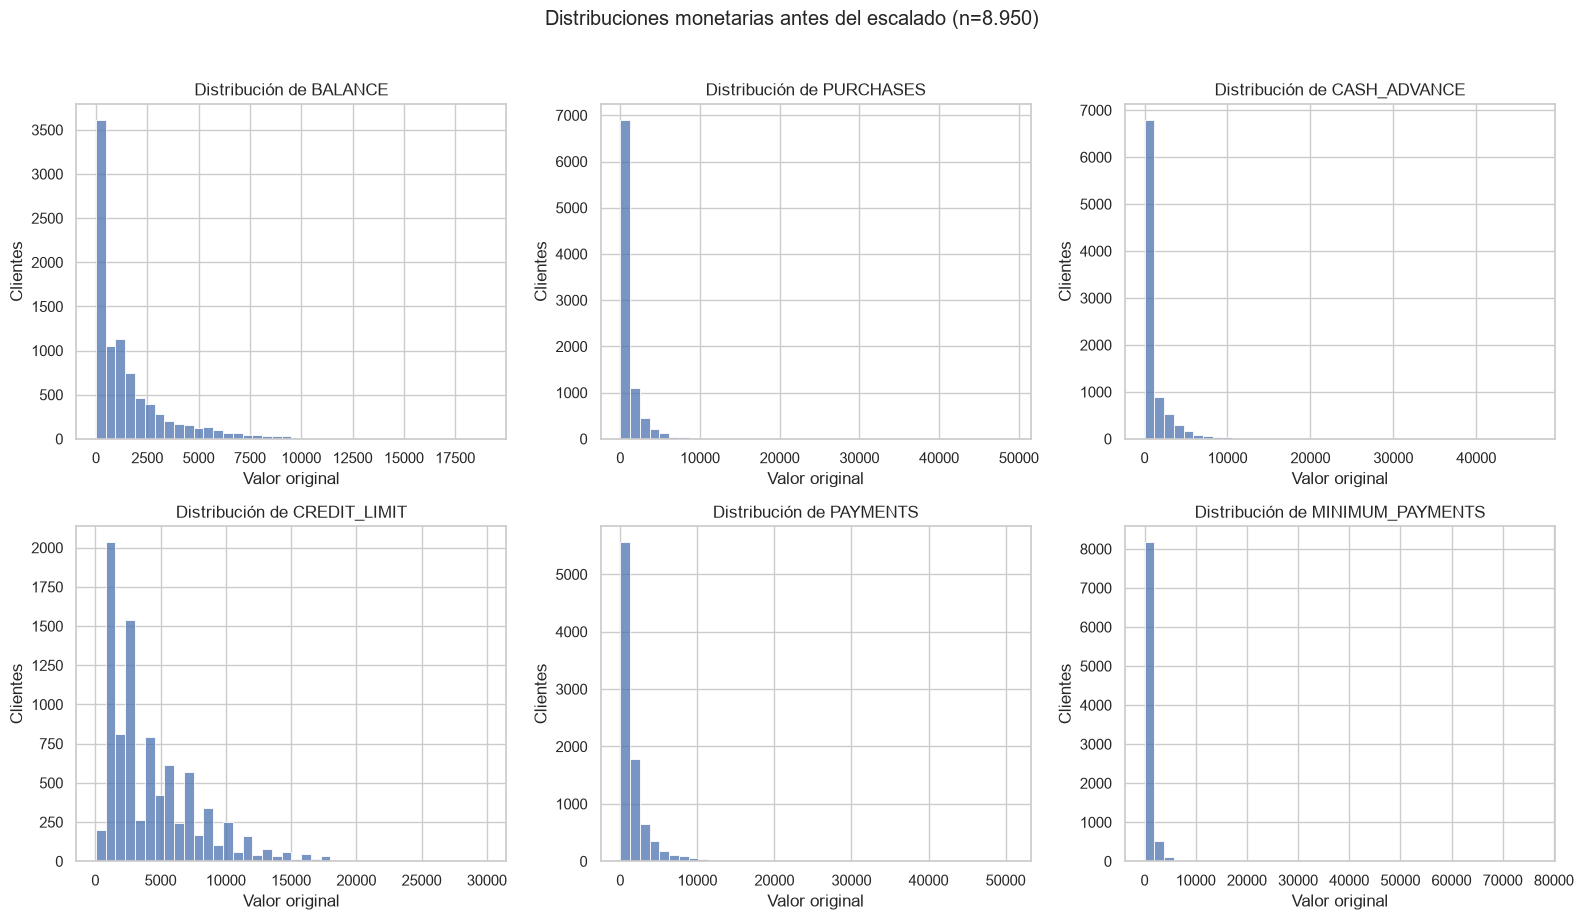

In [8]:
distribution_summary = pd.DataFrame({
    "skewness": credit_clean.skew(),
    "zero_percentage": credit_clean.eq(0).mean() * 100,
    "median": credit_clean.median(),
    "mean": credit_clean.mean(),
}).sort_values("skewness", ascending=False)
display(distribution_summary.round(2))

features_to_plot = [
    "BALANCE",
    "PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "MINIMUM_PAYMENTS",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for feature, ax in zip(features_to_plot, axes.flat):
    sns.histplot(
        credit_clean[feature],
        bins=40,
        color="#4C72B0",
        edgecolor="white",
        ax=ax,
    )
    ax.set_title(f"Distribución de {feature}")
    ax.set_xlabel("Valor original")
    ax.set_ylabel("Clientes")

fig.suptitle(
    "Distribuciones monetarias antes del escalado (n=8.950)",
    y=1.02,
)
plt.tight_layout()
plt.show()


### Interpretación de las distribuciones

Las variables monetarias no se parecen a una campana simétrica. Tienen una gran concentración de clientes en valores bajos y una cola pequeña de clientes con importes muy altos. Por ejemplo, `PURCHASES` tiene asimetría **8,14**, `ONEOFF_PURCHASES` **10,05** y `MINIMUM_PAYMENTS` **13,85** después de imputar.

Además, muchos ceros tienen significado conductual:

- El **51,71 %** no registra adelantos de efectivo.
- El **48,07 %** no registra compras de pago único.
- El **43,75 %** no registra compras a plazos.
- El **65,96 %** tiene `PRC_FULL_PAYMENT = 0`.

No son necesariamente datos faltantes: describen actividades que el cliente no realizó. La diferencia entre media y mediana también evidencia las colas; por ejemplo, la media de compras es 1.003,20, pero la mediana es solo 361,28.

Estas formas justifican el escalado. Como mejora futura se podría comparar el resultado actual con una transformación `log1p` en variables monetarias, pero no la aplicamos silenciosamente porque cambiaría la geometría y, por tanto, la definición de “cliente parecido”.


### Relaciones entre variables

La correlación de Pearson mide asociación lineal entre dos variables. Valores cercanos a 1 o -1 indican que cambian conjuntamente; valores cercanos a 0 no descartan relaciones no lineales.

Aquí sirve para detectar familias redundantes —por ejemplo, importe total de compras y sus componentes— y para entender por qué PCA puede resumir información. Correlación no implica causalidad.


,feature_1,feature_2,correlation,absolute_correlation
37,PURCHASES,ONEOFF_PURCHASES,0.917,0.917
110,PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,0.863,0.863
163,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,0.800,0.800
45,PURCHASES,PURCHASES_TRX,0.690,0.690
38,PURCHASES,INSTALLMENTS_PURCHASES,0.680,0.680
95,CASH_ADVANCE,CASH_ADVANCE_TRX,0.656,0.656
94,CASH_ADVANCE,CASH_ADVANCE_FREQUENCY,0.629,0.629
79,INSTALLMENTS_PURCHASES,PURCHASES_TRX,0.628,0.628
47,PURCHASES,PAYMENTS,0.603,0.603
113,PURCHASES_FREQUENCY,PURCHASES_TRX,0.568,0.568


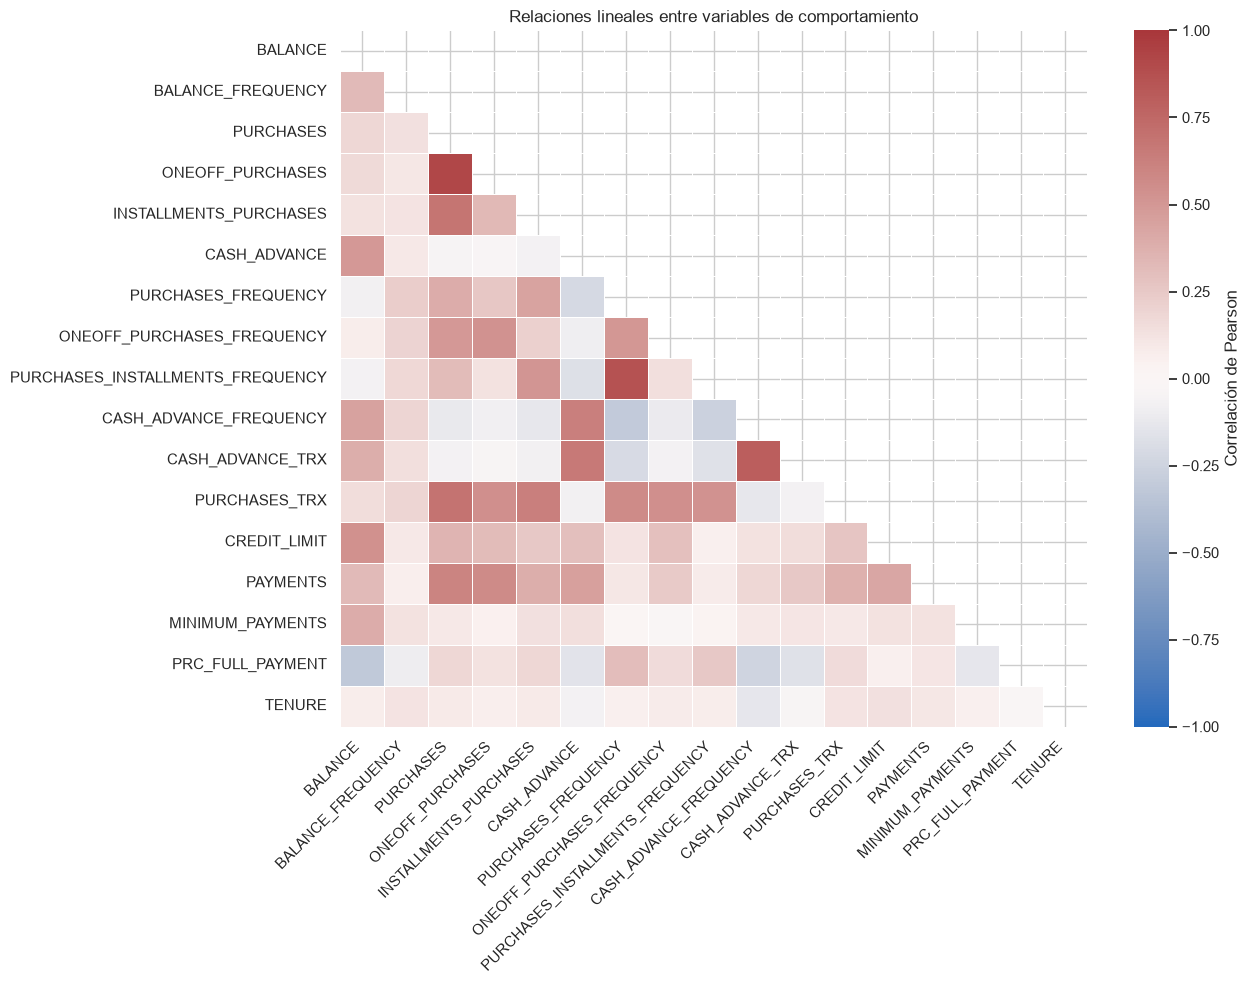

In [9]:
correlation_matrix = credit_clean.corr()
correlation_pairs = (
    correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
correlation_pairs["absolute_correlation"] = correlation_pairs[
    "correlation"
].abs()
display(
    correlation_pairs.sort_values(
        "absolute_correlation", ascending=False
    ).head(10).round(3)
)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.4,
    cbar_kws={"label": "Correlación de Pearson"},
    ax=ax,
)
ax.set_title("Relaciones lineales entre variables de comportamiento")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Interpretación de las correlaciones

Hay relaciones fuertes y coherentes con la definición de las variables. `PURCHASES` y `ONEOFF_PURCHASES` alcanzan una correlación de **0,917**; `PURCHASES_FREQUENCY` y `PURCHASES_INSTALLMENTS_FREQUENCY`, **0,863**; y `CASH_ADVANCE_FREQUENCY` y `CASH_ADVANCE_TRX`, **0,800**.

Esto indica **redundancia parcial**: varias columnas cuentan facetas similares de un mismo comportamiento. No eliminamos variables únicamente por correlación, porque una cantidad y su frecuencia no significan exactamente lo mismo. PCA permitirá resumir esa información compartida.

Importante: correlación no significa causalidad. El mapa solo mide asociación lineal; no demuestra, por ejemplo, que aumentar una frecuencia provoque un gasto mayor.


## 5. Escalado con StandardScaler

K-Means, PCA, clustering Ward, GMM y DBSCAN dependen de distancias o varianzas. Sin escalado, una diferencia de miles en `CREDIT_LIMIT` dominaría una diferencia de décimas en una frecuencia.

`StandardScaler` aplica, para cada variable:

\[
z = rac{x - \mu}{\sigma}
\]

Después del escalado cada variable tiene media cercana a 0 y desviación estándar cercana a 1.

**Limitación:** StandardScaler es sensible a valores extremos. Lo usamos porque es el método requerido y mantiene el contraste pedagógico; `RobustScaler` sería una alternativa razonable para comparar posteriormente.


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(credit_clean)

scaled_check = pd.DataFrame({
    "feature": credit_clean.columns,
    "scaled_mean": X_scaled.mean(axis=0),
    "scaled_std": X_scaled.std(axis=0),
})

print(f"Forma de X_scaled: {X_scaled.shape}")
print(
    "Mayor media absoluta:",
    f"{scaled_check['scaled_mean'].abs().max():.2e}",
)
print(
    "Mayor desviación respecto a std=1:",
    f"{(scaled_check['scaled_std'] - 1).abs().max():.2e}",
)


Forma de X_scaled: (8950, 17)
Mayor media absoluta: 2.79e-16
Mayor desviación respecto a std=1: 2.22e-16


### Interpretación del escalado

La matriz estandarizada tiene forma **(8.950, 17)**. Las medias quedan prácticamente en 0 y las desviaciones estándar en 1, con errores numéricos del orden de $10^{-16}$.

StandardScaler convierte cada valor en una distancia respecto a la media expresada en desviaciones estándar. Así, una diferencia en `CREDIT_LIMIT`, medida originalmente en miles, no domina automáticamente una diferencia en `PURCHASES_FREQUENCY`, medida entre 0 y 1.

El escalado no elimina valores extremos ni hace normales las distribuciones. Solo vuelve comparables sus escalas, requisito especialmente importante para PCA, K-Means, clustering jerárquico, DBSCAN y t-SNE.


## 6. PCA: reducción lineal de dimensionalidad

PCA crea componentes ortogonales que ordenan la variación del dataset. Lo utilizamos para:

1. cuantificar cuántas dimensiones resumen la información;
2. visualizar clientes en dos dimensiones;
3. comprender si la nube muestra separaciones evidentes.

PCA funciona mejor cuando la estructura es aproximadamente lineal. Sus componentes mezclan variables originales y pueden ser difíciles de interpretar. La varianza explicada tampoco mide utilidad comercial.


Componentes para 80 %: 7
Componentes para 90 %: 10
Componentes para 95 %: 12


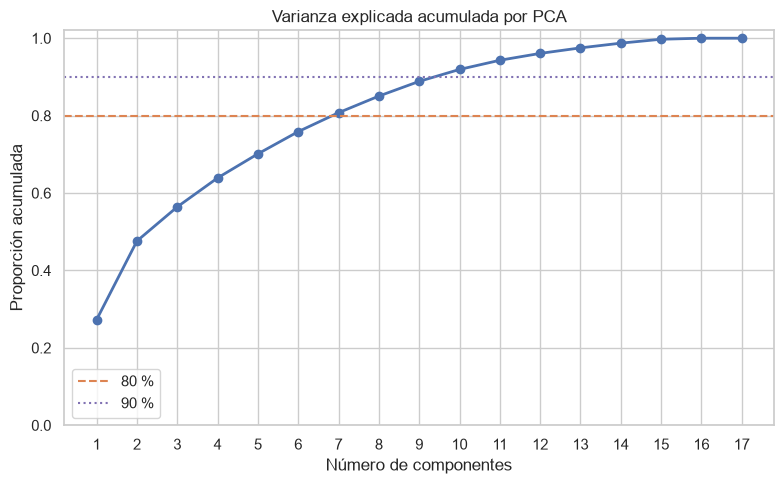

In [11]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

components_80 = int(np.argmax(cumulative_variance >= 0.80) + 1)
components_90 = int(np.argmax(cumulative_variance >= 0.90) + 1)
components_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)

print(f"Componentes para 80 %: {components_80}")
print(f"Componentes para 90 %: {components_90}")
print(f"Componentes para 95 %: {components_95}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    np.arange(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
    color="#4C72B0",
    linewidth=2,
)
ax.axhline(0.80, color="#DD8452", linestyle="--", label="80 %")
ax.axhline(0.90, color="#8172B3", linestyle=":", label="90 %")
ax.set(
    title="Varianza explicada acumulada por PCA",
    xlabel="Número de componentes",
    ylabel="Proporción acumulada",
)
ax.set_xticks(range(1, X_scaled.shape[1] + 1))
ax.set_ylim(0, 1.02)
ax.legend()
plt.tight_layout()
plt.show()


### Interpretación de la varianza explicada

PCA necesita **7 componentes** para conservar al menos el 80 % de la variabilidad, **10** para el 90 % y **12** para el 95 %. Esto revela que el comportamiento financiero no puede resumirse fielmente en una sola dimensión.

“Varianza explicada” significa información geométrica conservada, no porcentaje de clientes correctamente descritos. PCA tampoco conoce segmentos: crea combinaciones de variables que capturan variación global.

En este notebook usamos dos componentes principalmente para visualizar. Los modelos principales se entrenan con las 17 variables estandarizadas para no descartar información prematuramente.


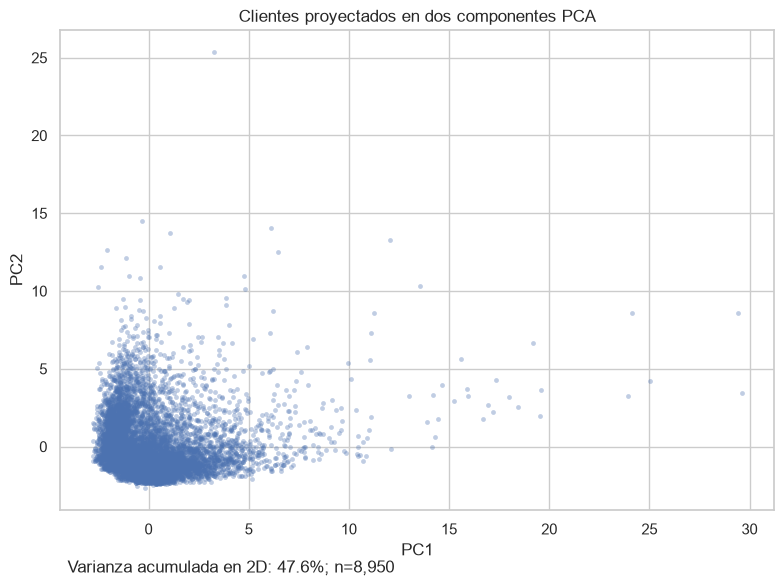

In [12]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)
pca_2d_variance = pca_2d.explained_variance_ratio_.sum()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    s=12,
    alpha=0.35,
    color="#4C72B0",
    linewidth=0,
)
ax.set(
    title="Clientes proyectados en dos componentes PCA",
    xlabel="PC1",
    ylabel="PC2",
)
ax.text(
    0.01,
    -0.13,
    f"Varianza acumulada en 2D: {pca_2d_variance:.1%}; n={len(credit_clean):,}",
    transform=ax.transAxes,
)
plt.tight_layout()
plt.show()


### Interpretación de la proyección en dos dimensiones

Los dos primeros componentes conservan aproximadamente **47,6 %** de la varianza total. La nube muestra una región muy densa cerca del centro y varias colas con clientes alejados, coherentes con las distribuciones asimétricas observadas.

No aparecen islas completamente separadas en este plano. Eso no demuestra que no existan grupos: más de la mitad de la variabilidad quedó fuera de la imagen. Tampoco debe confundirse distancia visual en PCA 2D con distancia exacta en las 17 dimensiones.

La lectura correcta es: hay estructura y observaciones extremas, pero la segmentación probablemente tendrá fronteras graduales, no categorías naturales perfectamente aisladas.


## 7. K-Means: selección del número de segmentos

K-Means minimiza la distancia cuadrática entre clientes y centroides. Funciona mejor con grupos compactos, aproximadamente esféricos y de dispersión parecida.

### Parámetros importantes

- `n_clusters`: número de grupos.
- `n_init`: número de inicializaciones; reduce el riesgo de una solución local deficiente.
- `random_state`: hace reproducible el experimento.

### Cómo elegimos `k`

- **Inercia:** suma de distancias cuadráticas a los centroides. Menor es mejor, pero siempre disminuye al añadir clusters.
- **Silhouette:** combina cohesión y separación. Se aproxima a 1 cuando los puntos están bien asignados y separados; cerca de 0 indica solapamiento.

La silhouette se estima sobre una muestra reproducible de 2.500 clientes para controlar el coste cuadrático.


,k,inertia,silhouette
0,2,127784.5345,0.2154
1,3,111973.9734,0.2378
2,4,99061.9398,0.2000
3,5,91490.4980,0.1965
4,6,84826.5920,0.2069
5,7,79506.9583,0.2191
6,8,74484.8801,0.2271
7,9,69828.6993,0.2289
8,10,66442.1796,0.2258


Mejor k según silhouette: 3


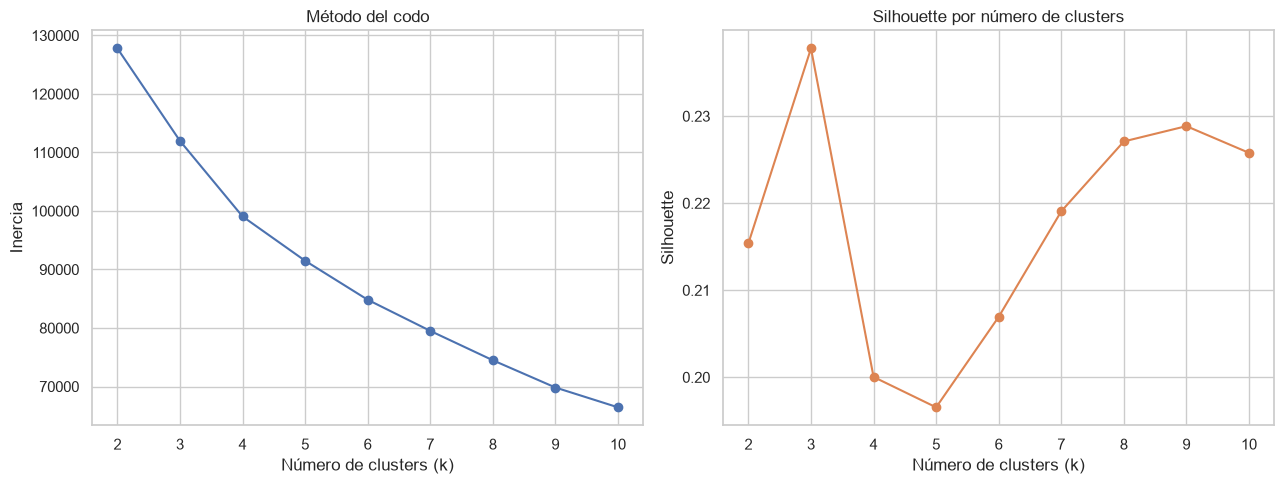

In [13]:
k_values = range(2, 11)
kmeans_search_rows = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=RANDOM_STATE,
    )
    labels = model.fit_predict(X_scaled)
    silhouette = silhouette_score(
        X_scaled,
        labels,
        sample_size=2500,
        random_state=RANDOM_STATE,
    )
    kmeans_search_rows.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette,
    })

kmeans_search = pd.DataFrame(kmeans_search_rows)
best_k = int(
    kmeans_search.loc[kmeans_search["silhouette"].idxmax(), "k"]
)
display(kmeans_search.round(4))
print(f"Mejor k según silhouette: {best_k}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(
    kmeans_search["k"],
    kmeans_search["inertia"],
    marker="o",
    color="#4C72B0",
)
axes[0].set(
    title="Método del codo",
    xlabel="Número de clusters (k)",
    ylabel="Inercia",
)
axes[1].plot(
    kmeans_search["k"],
    kmeans_search["silhouette"],
    marker="o",
    color="#DD8452",
)
axes[1].set(
    title="Silhouette por número de clusters",
    xlabel="Número de clusters (k)",
    ylabel="Silhouette",
)
plt.tight_layout()
plt.show()


### Interpretación de la búsqueda de $k$

La inercia disminuye cada vez que añadimos clusters, algo inevitable porque hay más centroides disponibles. Por sí sola no ofrece una respuesta única. El silhouette alcanza su máximo en **$k=3$**, con **0,2378**, y después cae antes de recuperarse parcialmente para valores mayores.

Elegimos **3 clusters** porque combina:

1. el mejor silhouette entre los valores probados;
2. una solución compacta y fácil de explicar;
3. una mejora clara de inercia respecto a $k=2$.

El valor 0,2378 es positivo, pero modesto. Sugiere que los grupos contienen estructura aprovechable y a la vez se solapan. No sería correcto presentar $k=3$ como una verdad absoluta: es una partición útil bajo estas variables, este escalado y la distancia euclídea.


### K-Means final y estabilidad

Sin etiqueta no basta con obtener una métrica alta. También necesitamos saber si distintas inicializaciones producen particiones parecidas.

Entrenamos el modelo final con más inicializaciones y repetimos K-Means con cinco semillas. Comparamos cada partición con la referencia mediante ARI. Aquí ARI **no usa una etiqueta real**: solo mide acuerdo entre dos ejecuciones.

- ARI cercano a 1: partición muy estable.
- ARI bajo: la solución depende de la inicialización y merece cautela.


In [14]:
kmeans_final = KMeans(
    n_clusters=best_k,
    n_init=30,
    random_state=RANDOM_STATE,
)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

cluster_sizes = (
    pd.Series(kmeans_labels, name="cluster")
    .value_counts()
    .sort_index()
    .rename("customers")
    .to_frame()
)
cluster_sizes["percentage"] = (
    cluster_sizes["customers"] / len(credit_clean) * 100
).round(2)
display(cluster_sizes)

stability_rows = []
for seed in [0, 7, 21, 42, 99]:
    seed_labels = KMeans(
        n_clusters=best_k,
        n_init=20,
        random_state=seed,
    ).fit_predict(X_scaled)
    stability_rows.append({
        "seed": seed,
        "ARI_vs_reference": adjusted_rand_score(
            kmeans_labels, seed_labels
        ),
    })

kmeans_stability = pd.DataFrame(stability_rows)
display(kmeans_stability.round(4))


,customers,percentage
cluster,,
0,6119,68.37
1,1596,17.83
2,1235,13.80


,seed,ARI_vs_reference
0,0,0.9997
1,7,0.9894
2,21,0.9992
3,42,0.9992
4,99,0.9926


### Interpretación del K-Means final y su estabilidad

La solución divide a los clientes en:

- Cluster 0: **6.119 clientes (68,37 %)**.
- Cluster 1: **1.596 clientes (17,83 %)**.
- Cluster 2: **1.235 clientes (13,80 %)**.

Los tamaños son desiguales, pero ningún cluster es diminuto. Al repetir K-Means con cinco semillas, el índice Rand ajustado frente a la solución de referencia queda entre **0,9894 y 0,9997**. Como 1 representa coincidencia perfecta, la asignación es muy estable frente a la inicialización aleatoria.

Estabilidad no equivale a verdad: solo indica que K-Means encuentra casi siempre la misma partición con esta preparación. La validez sustantiva depende de que los perfiles resultantes sean comprensibles y útiles.


## 8. Comparación de algoritmos

Aplicamos el mismo número de clusters y los mismos datos escalados para comparar hipótesis:

- **K-Means:** centroides y grupos compactos.
- **Aglomerativo Ward:** jerarquía de fusiones que minimiza varianza interna.
- **Gaussian Mixture:** mezcla probabilística de gaussianas con fronteras elípticas.

### Métricas internas

- Silhouette: mayor es mejor.
- Davies-Bouldin: menor es mejor.
- Calinski-Harabasz: mayor es mejor.

Ninguna métrica demuestra que un segmento sea comercialmente útil. Buscamos una solución equilibrada y después inspeccionamos perfiles.


In [15]:
agglomerative = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward",
)
agglomerative_labels = agglomerative.fit_predict(X_scaled)

gmm = GaussianMixture(
    n_components=best_k,
    covariance_type="full",
    n_init=5,
    random_state=RANDOM_STATE,
)
gmm_labels = gmm.fit_predict(X_scaled)

model_labels = {
    "K-Means": kmeans_labels,
    "Aglomerativo": agglomerative_labels,
    "GMM": gmm_labels,
}
comparison_rows = []
for model_name, labels in model_labels.items():
    comparison_rows.append({
        "model": model_name,
        "clusters": len(np.unique(labels)),
        "silhouette": silhouette_score(
            X_scaled,
            labels,
            sample_size=2500,
            random_state=RANDOM_STATE,
        ),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(
            X_scaled, labels
        ),
    })

clustering_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("silhouette", ascending=False)
)
clustering_comparison.round(4)


,model,clusters,silhouette,davies_bouldin,calinski_harabasz
0,K-Means,3,0.2378,1.5967,1605.0873
1,Aglomerativo,3,0.1568,1.8496,1239.3256
2,GMM,3,0.1083,2.6515,903.7407


### Interpretación de la comparación de modelos

Con tres grupos, **K-Means ofrece el mejor resultado interno**:

- Silhouette: **0,2378**, frente a 0,1568 del aglomerativo y 0,1083 de GMM. Más alto es mejor.
- Davies–Bouldin: **1,5967**, frente a 1,8496 y 2,6515. Más bajo es mejor.
- Calinski–Harabasz: **1.605,09**, frente a 1.239,33 y 903,74. Más alto es mejor.

Las tres métricas coinciden, por lo que elegimos K-Means como modelo principal. Aun así, todas son métricas internas: premian compactación y separación geométrica, no utilidad comercial ni estabilidad temporal.

GMM permite clusters elípticos y probabilísticos, mientras que el método aglomerativo construye una jerarquía. Su peor puntuación aquí no significa que sean malos algoritmos; significa que, con esta representación y tres grupos, describen peor la geometría observada.


### Dendrograma

El dendrograma muestra el orden y la distancia a la que se fusionan grupos. Una gran diferencia vertical antes de una fusión sugiere separaciones relevantes.

Se utiliza una muestra de 400 clientes porque construir y dibujar toda la jerarquía completa sería costoso e ilegible. El dendrograma orienta, pero no representa exactamente cada detalle del dataset completo.


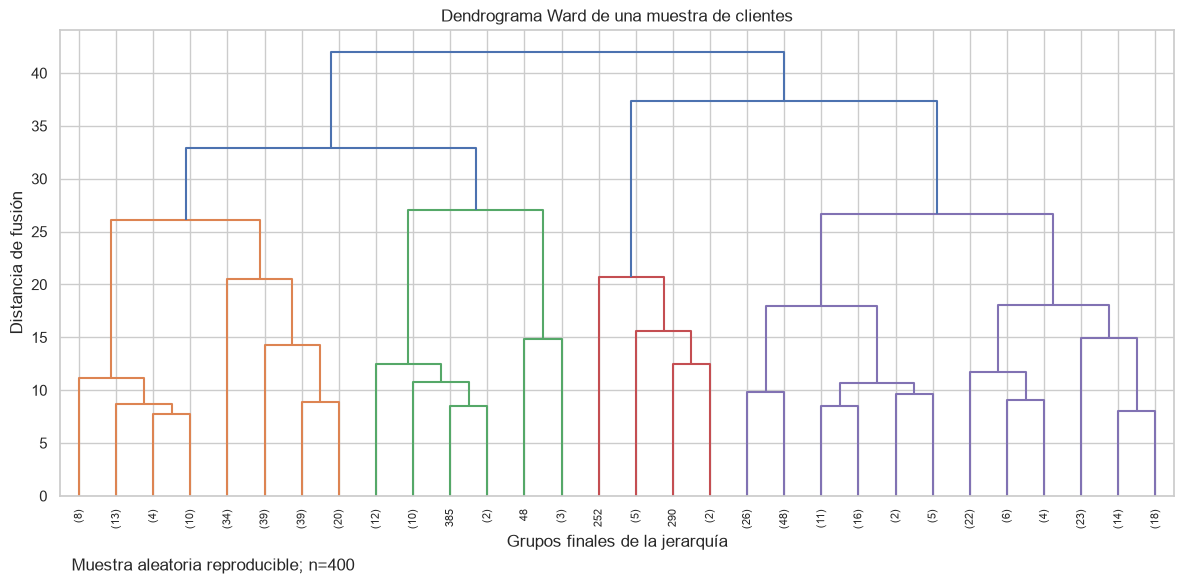

In [16]:
rng = np.random.default_rng(RANDOM_STATE)
dendrogram_indices = rng.choice(
    len(X_scaled),
    size=400,
    replace=False,
)
linkage_matrix = linkage(
    X_scaled[dendrogram_indices],
    method="ward",
)

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=8,
    ax=ax,
)
ax.set(
    title="Dendrograma Ward de una muestra de clientes",
    xlabel="Grupos finales de la jerarquía",
    ylabel="Distancia de fusión",
)
ax.text(
    0.01,
    -0.16,
    "Muestra aleatoria reproducible; n=400",
    transform=ax.transAxes,
)
plt.tight_layout()
plt.show()


### Interpretación del dendrograma

El dendrograma se construyó con una muestra reproducible de **400 clientes**, porque representar 8.950 hojas sería ilegible. Las fusiones bajas unen clientes relativamente parecidos; las fusiones altas combinan ramas más diferentes.

Los saltos de altura sugieren varias particiones posibles, no un corte inequívoco. El gráfico sirve para entender la lógica jerárquica y confirmar que existe estructura a distintos niveles, pero no debe usarse para afirmar que toda la población tiene exactamente la misma forma: solo visualiza una muestra.


## 9. DBSCAN: ¿existen regiones separadas por densidad?

DBSCAN agrupa puntos conectados por regiones densas y marca como ruido los puntos aislados.

### Parámetros

- `eps`: radio máximo de vecindad.
- `min_samples`: vecinos mínimos para considerar una región densa.

En alta dimensión las distancias tienden a parecerse y DBSCAN suele perder eficacia. Para visualizar su comportamiento lo aplicamos sobre PCA 2D. Esto reduce el problema, pero también significa que DBSCAN utiliza solo la información conservada por esas dos componentes.

Proponemos valores de `eps` a partir de cuantiles de la distancia al décimo vecino. La selección prioriza silhouette sin consultar ninguna etiqueta.


In [17]:
neighbors = NearestNeighbors(n_neighbors=10).fit(X_pca_2d)
neighbor_distances, _ = neighbors.kneighbors(X_pca_2d)
tenth_neighbor_distance = neighbor_distances[:, -1]

dbscan_rows = []
dbscan_labels_by_eps = {}
for quantile in [0.70, 0.80, 0.90, 0.95]:
    eps = float(np.quantile(tenth_neighbor_distance, quantile))
    labels = DBSCAN(
        eps=eps,
        min_samples=10,
    ).fit_predict(X_pca_2d)
    non_noise = labels != -1
    n_clusters = len(np.unique(labels[non_noise]))
    silhouette = np.nan
    if n_clusters >= 2 and non_noise.sum() > n_clusters:
        silhouette = silhouette_score(
            X_pca_2d[non_noise],
            labels[non_noise],
            sample_size=min(2500, int(non_noise.sum())),
            random_state=RANDOM_STATE,
        )
    dbscan_rows.append({
        "quantile": quantile,
        "eps": eps,
        "clusters": n_clusters,
        "noise_rate": 1 - non_noise.mean(),
        "silhouette_without_noise": silhouette,
    })
    dbscan_labels_by_eps[eps] = labels

dbscan_search = pd.DataFrame(dbscan_rows)
valid_dbscan = dbscan_search.dropna(
    subset=["silhouette_without_noise"]
)
dbscan_choice = valid_dbscan.sort_values(
    ["silhouette_without_noise", "noise_rate"],
    ascending=[False, True],
).iloc[0]
dbscan_labels = dbscan_labels_by_eps[float(dbscan_choice["eps"])]

display(dbscan_search.round(4))
print(f"Configuración seleccionada: eps={dbscan_choice['eps']:.4f}")
print(f"Clusters: {int(dbscan_choice['clusters'])}")
print(f"Ruido: {dbscan_choice['noise_rate']:.2%}")


,quantile,eps,clusters,noise_rate,silhouette_without_noise
0,0.70,0.1171,22,0.2326,-0.3884
1,0.80,0.1594,9,0.1512,0.0386
2,0.90,0.2498,6,0.0714,0.1389
3,0.95,0.3862,4,0.0363,0.3290


Configuración seleccionada: eps=0.3862
Clusters: 4
Ruido: 3.63%


### Interpretación de DBSCAN

DBSCAN se evaluó sobre PCA 2D como análisis exploratorio. La configuración seleccionada usa `eps ≈ 0,3862`, encuentra **4 clusters** y marca **3,63 %** de los puntos como ruido. Entre los candidatos probados, obtiene silhouette **0,3290** sin contar el ruido.

Ese 0,3290 **no es directamente comparable** con el 0,2378 de K-Means: DBSCAN trabaja aquí en solo dos componentes y excluye los puntos etiquetados como ruido al calcular silhouette. K-Means, en cambio, usa las 17 variables escaladas y asigna a todos los clientes.

El ejercicio muestra que una definición basada en densidad identifica núcleos densos y observaciones aisladas, pero es sensible a `eps`, `min_samples` y a la representación elegida. Por eso se conserva como contraste y no reemplaza automáticamente al modelo principal.


## 10. Visualización de K-Means con t-SNE

t-SNE preserva vecindades locales y puede mostrar estructuras no lineales. No es el espacio donde se entrenó K-Means: solo coloreamos la proyección con los segmentos ya calculados.

Precauciones:

- los ejes no tienen significado directo;
- las distancias globales pueden distorsionarse;
- islas visuales no demuestran que los clusters sean verdaderos;
- usamos una muestra reproducible de 2.500 clientes por coste computacional.


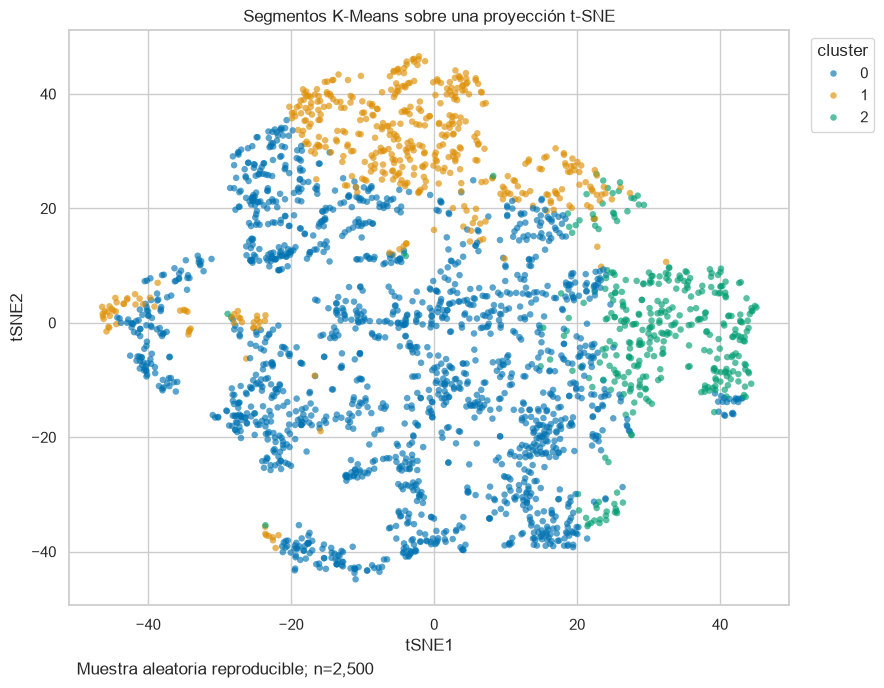

In [18]:
tsne_sample_size = min(2500, len(X_scaled))
rng = np.random.default_rng(RANDOM_STATE)
tsne_indices = rng.choice(
    len(X_scaled),
    size=tsne_sample_size,
    replace=False,
)

tsne = TSNE(
    n_components=2,
    perplexity=35,
    init="pca",
    learning_rate="auto",
    max_iter=750,
    random_state=RANDOM_STATE,
)
X_tsne = tsne.fit_transform(X_scaled[tsne_indices])

tsne_plot = pd.DataFrame({
    "tSNE1": X_tsne[:, 0],
    "tSNE2": X_tsne[:, 1],
    "cluster": kmeans_labels[tsne_indices].astype(str),
})
cluster_palette = dict(zip(
    sorted(tsne_plot["cluster"].unique()),
    sns.color_palette("colorblind", n_colors=best_k),
))

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(
    data=tsne_plot,
    x="tSNE1",
    y="tSNE2",
    hue="cluster",
    palette=cluster_palette,
    s=22,
    alpha=0.65,
    linewidth=0,
    ax=ax,
)
ax.set_title("Segmentos K-Means sobre una proyección t-SNE")
ax.text(
    0.01,
    -0.12,
    f"Muestra aleatoria reproducible; n={tsne_sample_size:,}",
    transform=ax.transAxes,
)
ax.legend(
    title="cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()


### Interpretación de t-SNE

La proyección t-SNE de una muestra de **2.500 clientes** muestra regiones dominadas por cada cluster, especialmente para los clusters 1 y 2, junto con zonas donde los colores se mezclan. Es coherente con un silhouette positivo pero moderado.

t-SNE intenta conservar vecindades locales; puede deformar distancias globales y crear huecos visuales. Sus ejes no tienen significado financiero directo y el gráfico no se usa para entrenar K-Means. Sirve como comprobación cualitativa, no como prueba definitiva de que existan tres categorías naturales.


## 11. Interpretación de los segmentos

Esta es la parte principal del caso. Un número de cluster no tiene significado por sí mismo: `cluster 0` no es mejor ni peor que `cluster 1`.

Calculamos dos vistas:

1. medias originales, útiles para expresar importes y frecuencias reales;
2. medias estandarizadas, útiles para comparar qué variables están por encima o debajo del cliente promedio.

El heatmap usa 0 como referencia global:

- valores positivos: el segmento está por encima de la media;
- valores negativos: está por debajo;
- intensidad: magnitud de la diferencia en desviaciones estándar.

Los nombres se asignarán a partir de varios indicadores, no de una sola variable.


,cluster,highest_features,lowest_features
0,0,"PRC_FULL_PAYMENT, TENURE, PURCHASES_INSTALLMEN...","BALANCE, CREDIT_LIMIT, CASH_ADVANCE_FREQUENCY"
1,1,"CASH_ADVANCE_FREQUENCY, CASH_ADVANCE, CASH_ADV...","PURCHASES_FREQUENCY, PURCHASES_INSTALLMENTS_FR..."
2,2,"PURCHASES_TRX, ONEOFF_PURCHASES_FREQUENCY, PUR...","CASH_ADVANCE_FREQUENCY, CASH_ADVANCE_TRX, CASH..."


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT
cluster,,,,,,
0,799.28,505.46,330.57,3270.78,909.56,0.16
1,3990.94,384.80,3867.14,6678.26,3019.55,0.03
2,2220.00,4268.52,458.42,7733.97,4151.28,0.30


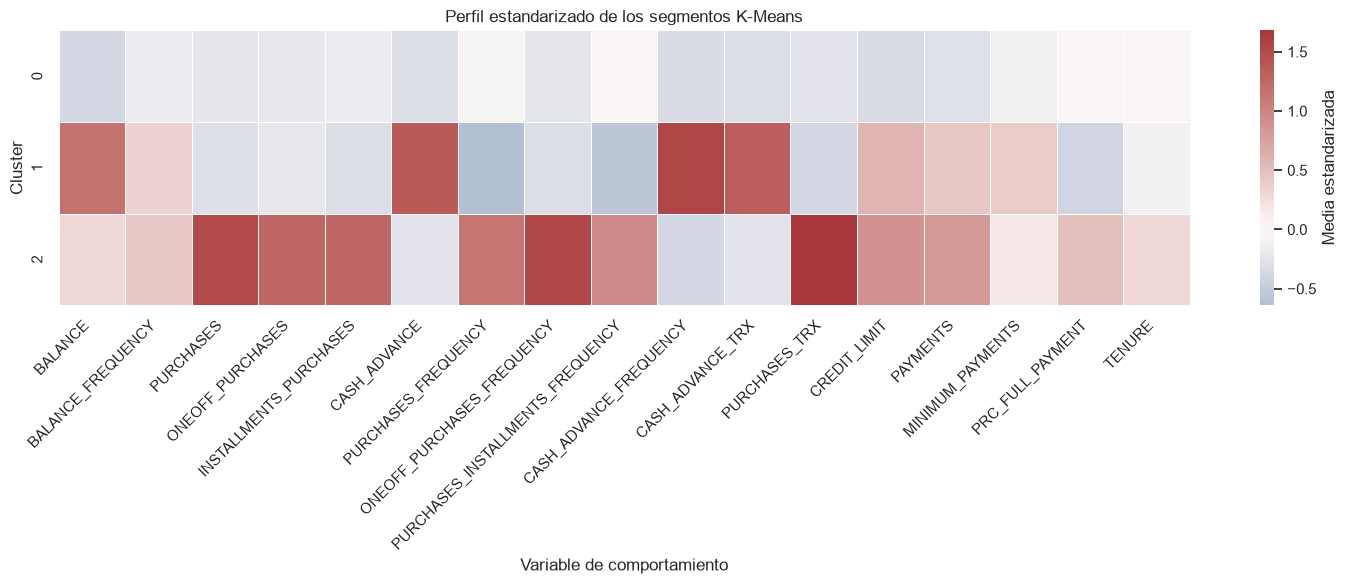

In [19]:
credit_segmented = credit_clean.copy()
credit_segmented["cluster"] = kmeans_labels

cluster_profiles_original = (
    credit_segmented.groupby("cluster").mean()
)
cluster_profiles_scaled = (
    pd.DataFrame(X_scaled, columns=credit_clean.columns)
    .assign(cluster=kmeans_labels)
    .groupby("cluster")
    .mean()
)

profile_drivers = []
for cluster_id, row in cluster_profiles_scaled.iterrows():
    highest = row.nlargest(3)
    lowest = row.nsmallest(3)
    profile_drivers.append({
        "cluster": cluster_id,
        "highest_features": ", ".join(highest.index),
        "lowest_features": ", ".join(lowest.index),
    })

profile_drivers = pd.DataFrame(profile_drivers)
display(profile_drivers)
display(
    cluster_profiles_original[[
        "BALANCE",
        "PURCHASES",
        "CASH_ADVANCE",
        "CREDIT_LIMIT",
        "PAYMENTS",
        "PRC_FULL_PAYMENT",
    ]].round(2)
)

fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(
    cluster_profiles_scaled,
    cmap="vlag",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Media estandarizada"},
    ax=ax,
)
ax.set_title("Perfil estandarizado de los segmentos K-Means")
ax.set_xlabel("Variable de comportamiento")
ax.set_ylabel("Cluster")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Interpretación de los perfiles de clientes

Los números de cluster son etiquetas arbitrarias. A partir de las medias originales y estandarizadas podemos proponer nombres descriptivos:

- **Cluster 0 — uso moderado o bajo (68,37 %):** saldo medio cercano a **799**, compras medias de **505**, adelantos de **331** y límite de crédito de **3.271**. Se encuentra por debajo del promedio en saldo, límite y uso de adelantos. Es el segmento mayoritario y más cercano al comportamiento general de baja intensidad.
- **Cluster 1 — financiación mediante adelantos (17,83 %):** saldo medio de **3.991** y adelantos de efectivo de **3.867**, con frecuencias y transacciones de adelanto muy superiores al promedio. Su proporción de pago completo es baja, alrededor de **0,03**. Puede representar clientes con mayor dependencia de liquidez financiada.
- **Cluster 2 — compradores intensivos (13,80 %):** compras medias de **4.269**, límite de **7.734** y pagos de **4.151**. Destaca tanto en compras puntuales como a plazos y en número de transacciones; usa poco el adelanto de efectivo y presenta la mayor proporción media de pago completo, aproximadamente **0,30**.

Estos nombres son resúmenes, no diagnósticos personales. No conocemos ingresos, riesgo, rentabilidad ni motivos de uso. Una decisión de negocio debería revisar distribuciones dentro de cada cluster —no solo medias— y validar los segmentos en otro periodo.


## 12. Detección de comportamientos atípicos

Isolation Forest aísla observaciones mediante divisiones aleatorias. Los clientes que requieren pocas divisiones reciben puntuaciones más anómalas.

Fijamos `contamination=0.02`, es decir, pedimos al modelo que marque aproximadamente un 2 % de clientes. Esta proporción es una hipótesis, no una verdad observada.

Un cliente atípico puede representar:

- un error de registro;
- posible fraude que requiere otras señales para confirmarse;
- un cliente premium con comportamiento poco habitual;
- una combinación rara pero legítima.

Por tanto, el modelo genera candidatos para revisión, no diagnósticos.


Clientes atípicos: 179
Porcentaje: 2.00%
Score mínimo/máximo: -0.1579 / 0.2338


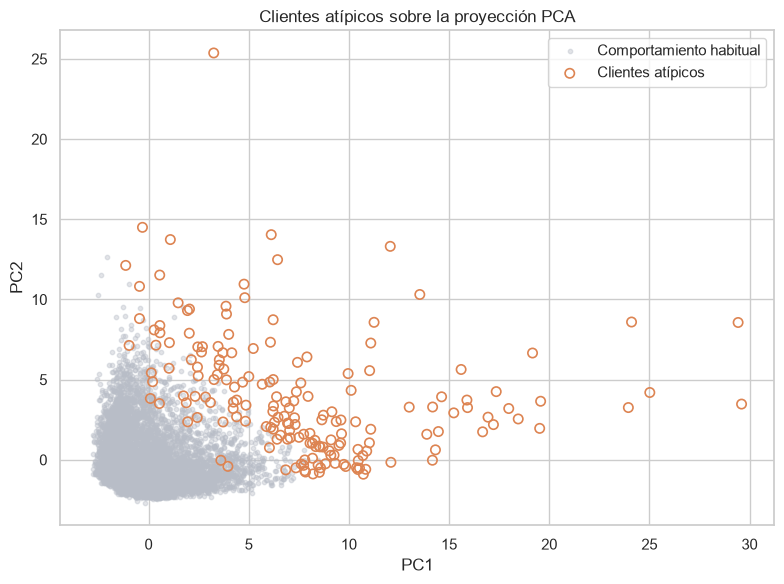

In [20]:
isolation_forest = IsolationForest(
    contamination=0.02,
    n_estimators=250,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
anomaly_labels = isolation_forest.fit_predict(X_scaled)
anomaly_scores = isolation_forest.decision_function(X_scaled)
is_anomaly = anomaly_labels == -1

print(f"Clientes atípicos: {int(is_anomaly.sum())}")
print(f"Porcentaje: {is_anomaly.mean():.2%}")
print(
    "Score mínimo/máximo:",
    f"{anomaly_scores.min():.4f} / {anomaly_scores.max():.4f}",
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    X_pca_2d[~is_anomaly, 0],
    X_pca_2d[~is_anomaly, 1],
    color="#B8BDC7",
    s=10,
    alpha=0.4,
    label="Comportamiento habitual",
)
ax.scatter(
    X_pca_2d[is_anomaly, 0],
    X_pca_2d[is_anomaly, 1],
    facecolors="none",
    edgecolors="#DD8452",
    s=45,
    linewidth=1.2,
    label="Clientes atípicos",
)
ax.set(
    title="Clientes atípicos sobre la proyección PCA",
    xlabel="PC1",
    ylabel="PC2",
)
ax.legend()
plt.tight_layout()
plt.show()


### Interpretación de anomalías

Isolation Forest, configurado con una contaminación esperada del 2 %, marca **179 clientes (2,00 %)** como atípicos. En la proyección PCA aparecen con frecuencia en las colas de la nube, aunque no todos los casos extremos se separan en ambas dimensiones.

“Atípico” significa difícil de aislar respecto al patrón multivariable habitual; no significa fraude ni error. Estos clientes pueden ser usuarios de alto valor, situaciones legítimas poco frecuentes, errores de registro o casos que requieren revisión.

La etiqueta debe utilizarse como señal de priorización para análisis adicional. Para detectar fraude harían falta etiquetas, contexto temporal y criterios de coste del error.


## Conclusiones finales

El análisis encuentra una segmentación reproducible de **tres perfiles**: un grupo mayoritario de uso moderado/bajo, un grupo orientado a adelantos de efectivo y un grupo de compras intensivas. K-Means es la opción principal porque supera al clustering aglomerativo y a GMM en las tres métricas internas evaluadas, y mantiene una estabilidad muy alta entre inicializaciones.

La conclusión debe expresarse con cautela. El silhouette de **0,2378** indica separación moderada: los segmentos resumen patrones, pero sus fronteras no son naturales ni perfectas. PCA 2D conserva solo el **47,6 %** de la variabilidad y t-SNE muestra mezcla en zonas de transición.

### Qué aprendimos metodológicamente

1. Los identificadores se preservan para trazabilidad, pero no deben definir distancias.
2. Los nulos se tratan antes del escalado y la mediana protege frente a distribuciones sesgadas.
3. Escalar es imprescindible cuando conviven importes, frecuencias y conteos.
4. Elegir $k$ requiere combinar métricas, gráficos, estabilidad e interpretabilidad.
5. Ningún algoritmo “descubre la verdad” sin supuestos: K-Means, GMM, jerárquico y DBSCAN construyen grupos con definiciones distintas.
6. Los perfiles deben interpretarse en unidades originales, aunque el entrenamiento se haga en unidades estandarizadas.

### Próximos pasos recomendados

- Comparar esta solución con una variante `log1p` para variables monetarias muy sesgadas.
- Evaluar estabilidad mediante remuestreo, no solo mediante semillas.
- Aplicar el modelo a otro periodo para comprobar estabilidad temporal.
- Revisar histogramas y cuantiles por cluster antes de diseñar acciones comerciales.
- Incorporar variables externas —por ejemplo ingresos, rentabilidad o mora— solo si su uso es legítimo y está bien documentado.

La segmentación es un punto de partida para formular preguntas y estrategias, no una decisión automática sobre personas.


---
## Para ir más allá (opcional)

Estas extensiones no forman parte del flujo principal, pero serían buenos experimentos posteriores:

- aplicar `log1p` a importes muy sesgados antes de escalar;
- comparar `StandardScaler` con `RobustScaler`;
- crear KPIs como uso del límite, compra media por transacción o relación pago/saldo;
- medir estabilidad mediante remuestreo, no solo semillas;
- probar UMAP y HDBSCAN;
- validar los segmentos con respuesta a campañas, rentabilidad, mora o retención.

La siguiente mejora prioritaria sería comprobar si los perfiles se mantienen estables al cambiar el periodo de datos. Sin validación temporal, no sabemos si la segmentación representa patrones persistentes o solo estos seis meses.
